## **Step 1: Mount Google Drive**

In [1]:
# from google.colab import drive

# drive.mount('/content/drive')

## **Step 2: Set Dataset Path**

In [2]:
# dataset_path = "/content/drive/MyDrive/Uni Life/Junior/3rd Term/Deep Learning/Project/Dataset"

dataset_path = "/Users/leonmarco/Downloads/Dataset"

## **Step 3: Import Libraries**

In [3]:
%pip install tensorflow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

## **Step 4: Prepare Image Dataset**

In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

## **Step 5: Load Training Dataset**

In [6]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 428 images belonging to 3 classes.


## **Step 6: Load Validation Dataset**

In [7]:
validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 107 images belonging to 3 classes.


## **Step 7: Build Simple CNN**

In [8]:
model = models.Sequential()

model.add(layers. Conv2D(32, (3,3),
                         activation="relu",
                         input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3),
                        activation="relu"))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation="relu"))

model.add(layers.Dense(train_data.num_classes, 
                       activation="softmax"))

/opt/miniconda3/envs/ccmaclrl/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## **Step 8: Compile Model**

In [9]:
model.compile (
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## **Step 9: Train Model**

In [10]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=validation_data
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.4322 - loss: 1.8770 - val_accuracy: 0.5981 - val_loss: 1.0283
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.6776 - loss: 0.8168 - val_accuracy: 0.6075 - val_loss: 0.9202
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8388 - loss: 0.4322 - val_accuracy: 0.6262 - val_loss: 1.3969
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.9042 - loss: 0.2751 - val_accuracy: 0.5794 - val_loss: 1.8246
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9463 - loss: 0.1590 - val_accuracy: 0.5701 - val_loss: 2.1516
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9322 - loss: 0.1709 - val_accuracy: 0.6449 - val_loss: 1.6459
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9673 - loss: 0.0903 - val_accuracy: 0.6355 - val_loss: 1.8390
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9790 - loss: 0.0641 - val_accuracy: 0.5981 - val_loss:

## **Step 10: Evaluate Model**

In [11]:
loss, accuracy = model.evaluate(validation_data)

print("Validation Accuracy: ", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 735ms/step - accuracy: 0.5888 - loss: 3.2758
Validation Accuracy:  0.5887850522994995


## **Step 11: Plot Accuracy**

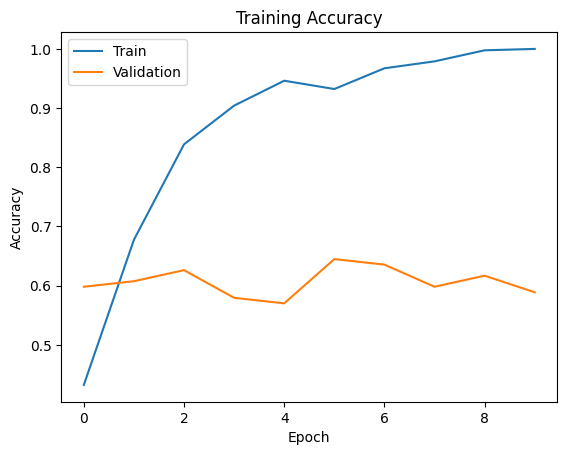

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

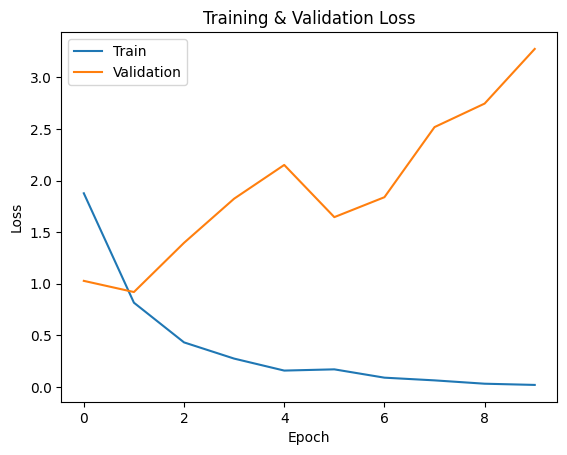

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

## **Test**

In [14]:
# import tkinter as tk
# from tkinter import filedialog
# from tensorflow.keras.preprocessing import image
# import numpy as np
# import matplotlib.pyplot as plt

# # 1. Create a local file browser popup
# root = tk.Tk()
# root.withdraw() # Hides the background main window
# root.call('wm', 'attributes', '.', '-topmost', True) # Forces the popup to the front

# print("Please select an image in the popup window...")
# # Opens the file explorer and saves the path of the file you click
# filename = filedialog.askopenfilename(title="Select an image to test")

# if not filename:
#     print("Upload canceled. Please run the cell again to select a file.")
# else:
#     print(f"Successfully loaded: {filename}")
    
#     # 2. Load the image and resize to the same size used in training
#     img = image.load_img(filename, target_size=(128,128))
     
#     # 3. Convert image to numpy array
#     img_array = image.img_to_array(img)
     
#     # 4. Normalize pixel values (same preprocessing used during training)
#     img_array = img_array / 255.0
     
#     # 5. Expand dimensions so the model receives a batch
#     img_array = np.expand_dims(img_array, axis=0)
     
#     # 6. Predict class
#     prediction = model.predict(img_array)
     
#     # 7. Get predicted class index
#     predicted_class = np.argmax(prediction)
     
#     # 8. Retrieve class labels from training dataset
#     # (Requires train_data to be loaded in memory)
#     class_labels = list(train_data.class_indices.keys())
     
#     # 9. Display the image
#     plt.imshow(img)
#     plt.axis('off')
     
#     # 10. Display predicted label
#     print("Predicted Class:", class_labels[predicted_class])
#     plt.title("Prediction: " + class_labels[predicted_class])
#     plt.show()

# --------------------------------------------------------------------

# from google.colab import files
# from tensorflow.keras.preprocessing import image
# import numpy as np
# import matplotlib.pyplot as plt

# # Upload an image file
# uploaded = files.upload()
 
# # Get uploaded file name
# filename = list(uploaded.keys())[0]
 
# # Load the image and resize to the same size used in training
# img = image.load_img(filename, target_size=(128,128))
 
# # Convert image to numpy array
# img_array = image.img_to_array(img)
 
# # Normalize pixel values (same preprocessing used during training)
# img_array = img_array / 255.0
 
# # Expand dimensions so the model receives a batch
# img_array = np.expand_dims(img_array, axis=0)
 
# # Predict class
# prediction = model.predict(img_array)
 
# # Get predicted class index
# predicted_class = np.argmax(prediction)
 
# # Retrieve class labels from training dataset
# class_labels = list(train_data.class_indices.keys())
 
# # Display the image
# plt.imshow(img)
# plt.axis('off')
 
# # Display predicted label
# print("Predicted Class:", class_labels[predicted_class])
 
# # Show image with title
# plt.title("Prediction: " + class_labels[predicted_class])
# plt.show()